# Azure Stay - CP372 Final Project
## Channel Profitability & Distribution Cost Analysis

โปรเจ็กต์นี้สอดคล้องกับโจทย์ final project เรื่อง **High Distribution Costs / Commission Trap**  
และต่อยอดจากงานเดิม **HW3_Hotel_Descriptive_Diagnostic** กับ **Project Canvas**

### เป้าหมาย
1. เปรียบเทียบ **Net ADR** ระหว่าง Direct กับ OTA  
2. เปรียบเทียบ **Cost %** ของ commission model แต่ละแบบ  
3. หาช่องทางและ rate code ที่มี **Cancellation Rate สูง**  
4. ประเมินประสิทธิภาพของ **Direct Marketing Spend**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 1) Load data

> ถ้ารันบน Colab ให้ upload โฟลเดอร์ `data/` หรือแก้ path ให้ตรงกับที่เก็บไฟล์


In [3]:
DATA_PATH = '.'

fact_bookings = pd.read_csv(f'{DATA_PATH}/fact_bookings.csv', parse_dates=['booking_date', 'check_in_date'])
dim_channels = pd.read_csv(f'{DATA_PATH}/dim_channels.csv')
dim_rate_codes = pd.read_csv(f'{DATA_PATH}/dim_rate_codes.csv')
fact_marketing_spend = pd.read_csv(f'{DATA_PATH}/fact_marketing_spend.csv', parse_dates=['spend_date'])

print(fact_bookings.shape, dim_channels.shape, dim_rate_codes.shape, fact_marketing_spend.shape)
fact_bookings.head()

(5000, 9) (6, 6) (5, 3) (2322, 6)


,booking_id,booking_date,check_in_date,channel_id,rate_code_id,gross_room_revenue,commission_amount,net_room_revenue,status
0,RES-01830,2024-11-10,2025-01-06,CH_05,RT_CORP,1746.0,139.68,1606.32,Checked-Out
1,RES-01468,2024-11-13,2025-01-09,CH_05,RT_CORP,9360.0,748.80,8611.20,Checked-Out
2,RES-01471,2024-11-13,2025-01-12,CH_03,RT_ADV,4680.0,936.00,3744.00,Checked-Out
3,RES-02558,2024-11-15,2025-01-04,CH_02,RT_ADV,9360.0,1684.80,7675.20,Checked-Out
4,RES-03652,2024-11-15,2025-01-03,CH_02,RT_ADV,7020.0,1263.60,5756.40,Checked-Out


## 2) Data model

In [4]:
df = (
    fact_bookings
    .merge(dim_channels, on='channel_id', how='left')
    .merge(dim_rate_codes, on='rate_code_id', how='left')
)
df.head()

,booking_id,booking_date,check_in_date,channel_id,rate_code_id,gross_room_revenue,commission_amount,net_room_revenue,status,channel_name,channel_type,commission_model,default_commission_rate,contract_owner,rate_name,is_commissionable
0,RES-01830,2024-11-10,2025-01-06,CH_05,RT_CORP,1746.0,139.68,1606.32,Checked-Out,Corporate Sales,B2B,Net Rate,0.08,Carol,Corporate Rate,False
1,RES-01468,2024-11-13,2025-01-09,CH_05,RT_CORP,9360.0,748.80,8611.20,Checked-Out,Corporate Sales,B2B,Net Rate,0.08,Carol,Corporate Rate,False
2,RES-01471,2024-11-13,2025-01-12,CH_03,RT_ADV,4680.0,936.00,3744.00,Checked-Out,Expedia,OTA,Percentage,0.20,Bob,Advance Purchase,True
3,RES-02558,2024-11-15,2025-01-04,CH_02,RT_ADV,9360.0,1684.80,7675.20,Checked-Out,Booking.com,OTA,Percentage,0.18,Bob,Advance Purchase,True
4,RES-03652,2024-11-15,2025-01-03,CH_02,RT_ADV,7020.0,1263.60,5756.40,Checked-Out,Booking.com,OTA,Percentage,0.18,Bob,Advance Purchase,True


## 3) KPI 1: Net ADR by channel type

In [5]:
non_cancel = df[df['status'] != 'Cancelled'].copy()

net_adr = (
    non_cancel.groupby('channel_type')
    .agg(
        bookings=('booking_id', 'count'),
        gross_room_revenue=('gross_room_revenue', 'sum'),
        commission_amount=('commission_amount', 'sum'),
        net_room_revenue=('net_room_revenue', 'sum')
    )
)

net_adr['net_adr'] = net_adr['net_room_revenue'] / net_adr['bookings']
net_adr = net_adr.sort_values('net_adr', ascending=False)
net_adr.round(2)

,bookings,gross_room_revenue,commission_amount,net_room_revenue,net_adr
channel_type,,,,,
Direct,2022,14864382.0,0.00,14864382.00,7351.33
OTA,1921,13484310.0,2548563.60,10935746.40,5692.74
B2B,384,2166480.0,133617.56,2032862.44,5293.91


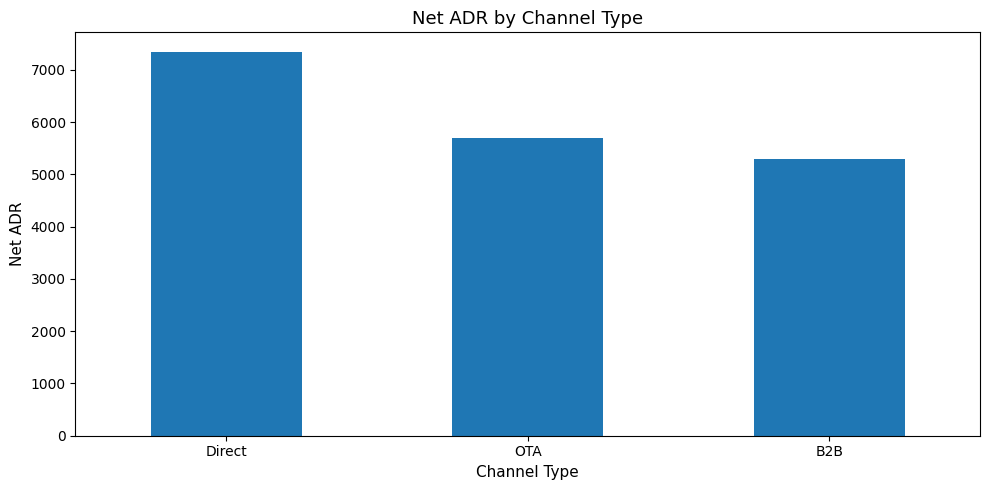

In [6]:
ax = net_adr['net_adr'].plot(kind='bar')
ax.set_title('Net ADR by Channel Type')
ax.set_ylabel('Net ADR')
ax.set_xlabel('Channel Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4) KPI 2: Commission Cost % by commission model

In [7]:
cost_pct = (
    non_cancel.groupby('commission_model')
    .agg(
        gross_room_revenue=('gross_room_revenue', 'sum'),
        commission_amount=('commission_amount', 'sum')
    )
)
cost_pct['cost_pct'] = (cost_pct['commission_amount'] / cost_pct['gross_room_revenue']) * 100
cost_pct.sort_values('cost_pct').round(2)

,gross_room_revenue,commission_amount,cost_pct
commission_model,,,
Flat Fee,15932430.0,45743.00,0.29
Net Rate,1098432.0,87874.56,8.00
Percentage,13484310.0,2548563.60,18.90


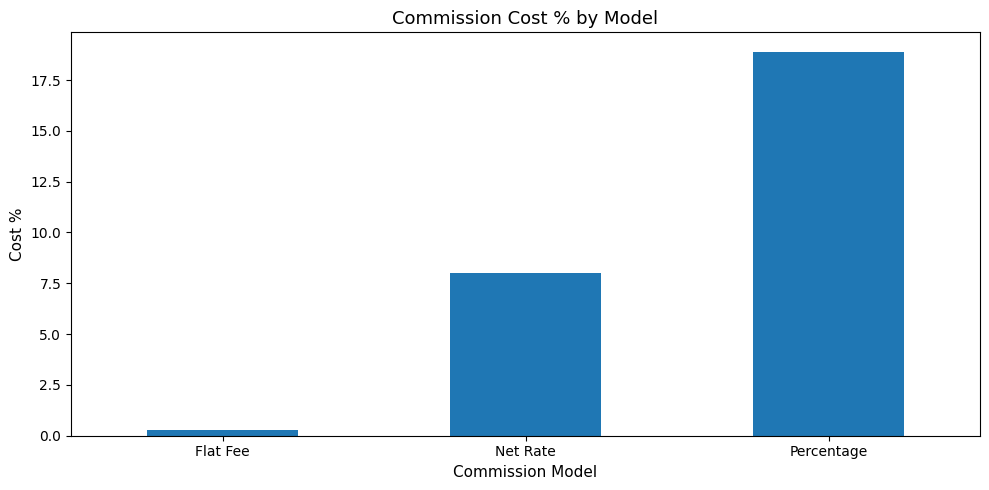

In [8]:
ax = cost_pct['cost_pct'].sort_values().plot(kind='bar')
ax.set_title('Commission Cost % by Model')
ax.set_ylabel('Cost %')
ax.set_xlabel('Commission Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5) KPI 3: Cancellation analysis

In [9]:
cancel_by_channel = (
    df.assign(is_cancelled=(df['status'] == 'Cancelled').astype(int))
      .groupby('channel_name')['is_cancelled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

cancel_by_rate = (
    df.assign(is_cancelled=(df['status'] == 'Cancelled').astype(int))
      .groupby('rate_name')['is_cancelled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print('Cancellation Rate by Channel (%)')
display(cancel_by_channel.round(2).to_frame())

print('Cancellation Rate by Rate Code (%)')
display(cancel_by_rate.round(2).to_frame())

Cancellation Rate by Channel (%)


,is_cancelled
channel_name,
Expedia,18.90
Booking.com,15.40
Travel Agent,12.86
Direct Website,12.73
Corporate Sales,4.29
Walk-in,4.20


Cancellation Rate by Rate Code (%)


,is_cancelled
rate_name,
Promotional Rate,26.97
Package Rate,9.66
Best Available Rate,9.38
Advance Purchase,5.25
Corporate Rate,4.66


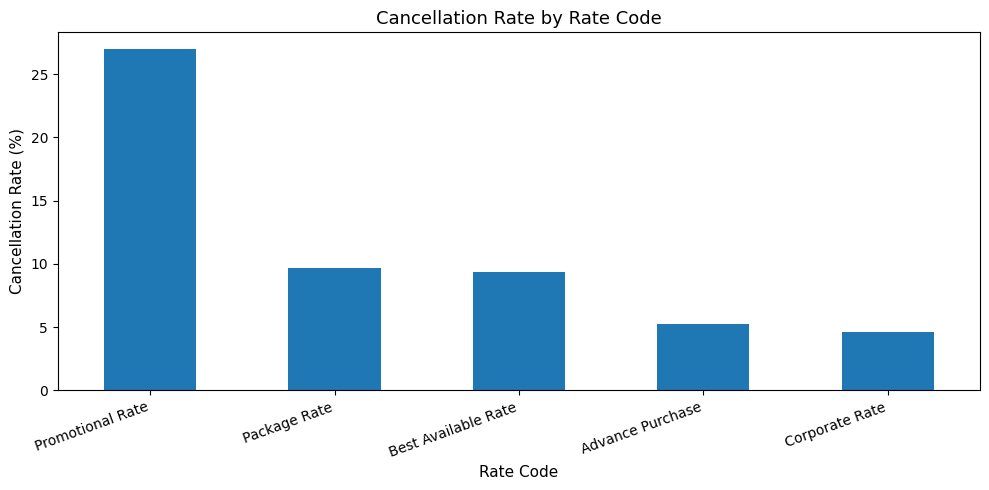

In [10]:
ax = cancel_by_rate.plot(kind='bar')
ax.set_title('Cancellation Rate by Rate Code')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Rate Code')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 6) KPI 4: Direct marketing efficiency

In [11]:
direct_bookings = df[(df['channel_id'] == 'CH_01') & (df['status'] != 'Cancelled')].copy()

daily_direct_bookings = (
    direct_bookings.groupby(direct_bookings['booking_date'].dt.date)
    .size()
    .reset_index(name='direct_bookings')
)

daily_spend = (
    fact_marketing_spend.groupby(fact_marketing_spend['spend_date'].dt.date)
    .agg(cost_amount=('cost_amount', 'sum'), clicks=('clicks', 'sum'))
    .reset_index()
)

marketing = daily_spend.merge(
    daily_direct_bookings,
    left_on='spend_date',
    right_on='booking_date',
    how='left'
).drop(columns=['booking_date']).fillna({'direct_bookings': 0})

marketing['cost_per_booking'] = marketing['cost_amount'] / marketing['direct_bookings'].replace(0, np.nan)

marketing.describe().round(2)

,cost_amount,clicks,direct_bookings,cost_per_booking
count,774.00,774.00,774.00,495.00
mean,2611.54,293.42,1.99,1295.81
std,352.82,37.30,2.18,893.78
min,1822.73,201.00,0.00,217.81
25%,2340.89,266.00,0.00,585.06
50%,2584.50,292.50,1.00,939.20
75%,2850.95,317.00,3.00,2186.18
max,3795.75,412.00,12.00,3587.87


In [12]:
monthly_marketing = marketing.copy()
monthly_marketing['month'] = pd.to_datetime(monthly_marketing['spend_date']).dt.to_period('M').astype(str)

monthly_summary = (
    monthly_marketing.groupby('month')
    .agg(cost_amount=('cost_amount', 'sum'),
         clicks=('clicks', 'sum'),
         direct_bookings=('direct_bookings', 'sum'))
)
monthly_summary['cost_per_booking'] = monthly_summary['cost_amount'] / monthly_summary['direct_bookings'].replace(0, np.nan)
monthly_summary.tail(12).round(2)

,cost_amount,clicks,direct_bookings,cost_per_booking
month,,,,
2026-01,91503.11,10209,11.0,8318.46
2026-02,68633.30,7628,14.0,4902.38
2026-03,79042.28,8813,15.0,5269.49
2026-04,77257.18,8625,9.0,8584.13
2026-05,75464.84,8638,13.0,5804.99
2026-06,78506.54,8689,14.0,5607.61
2026-07,74711.43,8553,9.0,8301.27
2026-08,75426.29,8530,9.0,8380.70
2026-09,74280.16,8299,10.0,7428.02


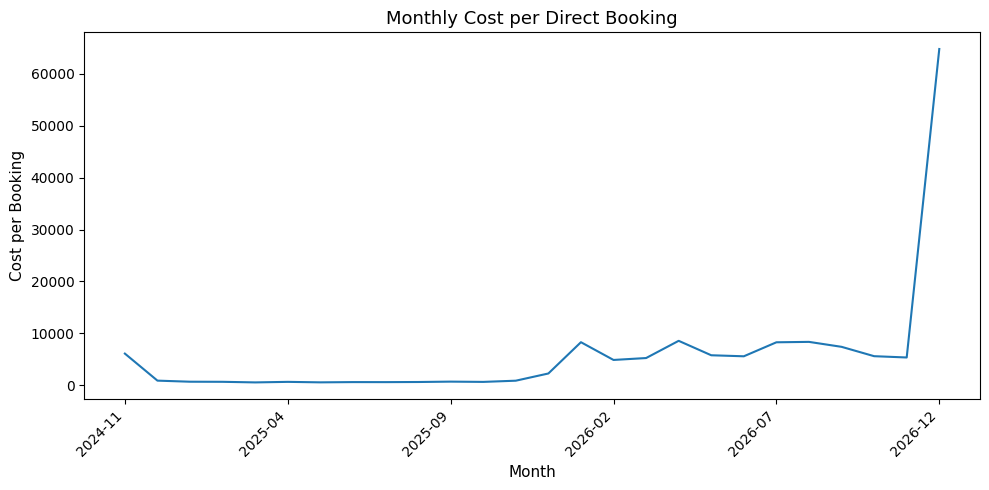

In [13]:
ax = monthly_summary['cost_per_booking'].dropna().plot()
ax.set_title('Monthly Cost per Direct Booking')
ax.set_ylabel('Cost per Booking')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7) Executive summary

In [14]:
direct_net_adr = net_adr.loc['Direct', 'net_adr']
ota_net_adr = net_adr.loc['OTA', 'net_adr']
flat_fee_cost = cost_pct.loc['Flat Fee', 'cost_pct']
percentage_cost = cost_pct.loc['Percentage', 'cost_pct']
promo_cancel = cancel_by_rate.loc['Promotional Rate']
expedia_cancel = cancel_by_channel.loc['Expedia']

print(f'Direct Net ADR = {direct_net_adr:,.2f}')
print(f'OTA Net ADR = {ota_net_adr:,.2f}')
print(f'Direct advantage over OTA = {direct_net_adr - ota_net_adr:,.2f}')
print(f'Flat Fee Cost % = {flat_fee_cost:.2f}%')
print(f'Percentage Cost % = {percentage_cost:.2f}%')
print(f'Promotional Rate Cancellation = {promo_cancel:.2f}%')
print(f'Expedia Cancellation = {expedia_cancel:.2f}%')

Direct Net ADR = 7,351.33
OTA Net ADR = 5,692.74
Direct advantage over OTA = 1,658.59
Flat Fee Cost % = 0.29%
Percentage Cost % = 18.90%
Promotional Rate Cancellation = 26.97%
Expedia Cancellation = 18.90%


## 8) Recommendations

### Recommendation 1: Shift mix from OTA to Direct / low-cost channels
- เพิ่มสัดส่วน Direct Website, Walk-in และ Corporate
- จำกัด inventory ใน OTA ที่ cost สูง โดยเฉพาะช่วง high demand

### Recommendation 2: Tighten promotional cancellation policy
- สำหรับ Promotional Rate ใช้ non-refundable หรือ deposit required
- ลด free cancellation ในช่วง demand สูง

### Recommendation 3: Optimize direct marketing before scaling spend
- ทำ A/B testing หน้า booking engine
- วัด conversion by campaign / platform
- เพิ่มสิทธิพิเศษ direct booking แทนการลดราคาหนัก
